<a href="https://colab.research.google.com/github/S84v/cats-vs-dogs/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
(data_train, data_val, data_test), data_info = tfds.load('cats_vs_dogs',
                                               split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
                                               shuffle_files=True,
                                               as_supervised=True,
                                               with_info=True
                                               )

In [3]:
print("Traing set size: ", len(data_train))
print("Validation set size: ", len(data_val))
print("Test set size: ", len(data_test))

Traing set size:  16283
Validation set size:  3490
Test set size:  3489


In [4]:
def normalize_img(image, label):
    image = tf.image.resize(image, (128, 128))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [5]:
# Training pipeline
data_train = data_train.map(normalize_img)
# data_train = data_train.cache()
data_train = data_train.shuffle(1000)
data_train = data_train.batch(32)
data_train = data_train.prefetch(tf.data.AUTOTUNE)

In [6]:
# Validation pipeline
data_val = data_val.map(normalize_img)
data_val = data_val.batch(32)
# data_val = data_val.cache()
data_val = data_val.prefetch(tf.data.AUTOTUNE)

In [7]:
# Testing pipeline
data_test = data_test.map(normalize_img)
data_test = data_test.batch(32)
# data_test = data_test.cache()

In [8]:
# Flat sequential model

model = keras.models.Sequential([
    layers.Input(shape = (128, 128, 3)),
    layers.Flatten(),
    layers.Dense(10, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [9]:
model.compile(optimizer=keras.optimizers.Adam(0.001),
              loss = keras.losses.binary_crossentropy,
              metrics = [keras.metrics.BinaryAccuracy()])

In [10]:
model.fit(data_train, epochs=10, validation_data=data_val)

Epoch 1/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 27s 47ms/step - binary_accuracy: 0.5014 - loss: 0.7387 - val_binary_accuracy: 0.4994 - val_loss: 0.6931
Epoch 2/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - binary_accuracy: 0.5033 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss: 0.6932
Epoch 3/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - binary_accuracy: 0.5033 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss: 0.6932
Epoch 4/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - binary_accuracy: 0.5033 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss: 0.6931
Epoch 5/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - binary_accuracy: 0.5033 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss: 0.6932
Epoch 6/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 42ms/step - binary_accuracy: 0.5033 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss: 0.6931
Epoch 7/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - binary_accuracy: 0.5022 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss:

In [17]:
print(model.history.history.keys())

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])


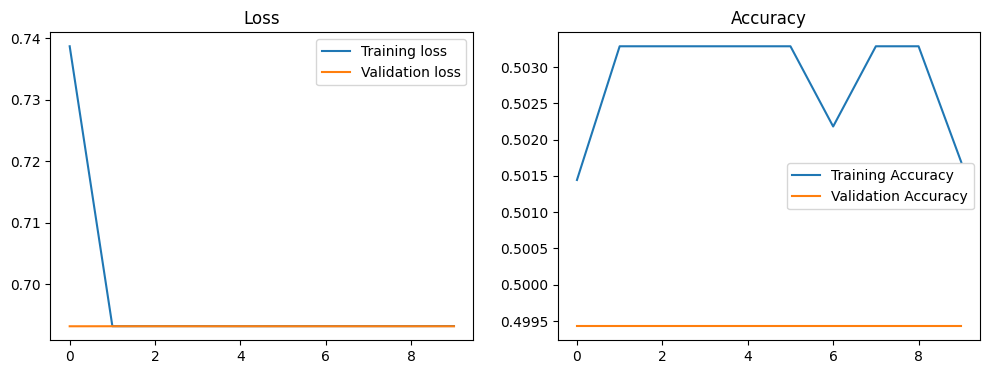

In [21]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].plot(model.history.history["loss"], label = "Training loss")
axes[0].plot(model.history.history["val_loss"], label = "Validation loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(model.history.history['binary_accuracy'], label = "Training Accuracy")
axes[1].plot(model.history.history['val_binary_accuracy'], label = "Validation Accuracy")
axes[1].set_title('Accuracy')
axes[1].legend()

plt.show()